# **Import the libraries**

In [1]:
import pandas as pd          
import numpy as np           
from sklearn.linear_model import LinearRegression   
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_absolute_error      
from sklearn.metrics import r2_score                 
from sklearn.metrics import mean_squared_error       
import matplotlib.pyplot as plt  
import seaborn as sns             
print("All libraries loaded successfully ✅")

All libraries loaded successfully ✅


# **Data Exploration**

## *Load The Data*

In [2]:
df = pd.read_csv("C:\\Users\\abhay\\OneDrive\\Desktop\\ML learning\\Linear Regression\\House Price\\Data\\house_price.csv")
print("Data Loaded✅")

Data Loaded✅


## *Exploration*

In [3]:
print(f"The Data Shape is {df.shape}")

The Data Shape is (612, 7)


In [4]:
# First 5 Rows
df.head()

,area_sqft,bedrooms,age_years,distance_to_metro_km,floor_number,has_parking,price_lakh
0,3674.0,2.0,5.0,NaN,4.0,0.0,167.31
1,1360.0,3.0,26.0,NaN,16.0,1.0,67.86
2,1794.0,3.0,39.0,12.7,18.0,1.0,81.65
3,1630.0,4.0,33.0,19.1,18.0,1.0,80.48
4,1595.0,3.0,11.0,5.3,11.0,1.0,106.39


In [5]:
# Last 5 rows
df.tail()

,area_sqft,bedrooms,age_years,distance_to_metro_km,floor_number,has_parking,price_lakh
607,2565.0,3.0,33.0,4.1,8.0,1.0,118.48
608,2568.0,4.0,11.0,12.2,13.0,0.0,145.71
609,1297.0,4.0,17.0,12.0,18.0,0.0,79.49
610,2561.0,4.0,23.0,19.6,11.0,1.0,119.91
611,2979.0,3.0,0.0,27.2,14.0,1.0,138.29


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area_sqft             592 non-null    float64
 1   bedrooms              612 non-null    float64
 2   age_years             612 non-null    float64
 3   distance_to_metro_km  597 non-null    float64
 4   floor_number          612 non-null    float64
 5   has_parking           612 non-null    float64
 6   price_lakh            612 non-null    float64
dtypes: float64(7)
memory usage: 33.6 KB


In [7]:
df.describe()

,area_sqft,bedrooms,age_years,distance_to_metro_km,floor_number,has_parking,price_lakh
count,592.000000,612.000000,612.000000,597.000000,612.000000,612.000000,612.000000
mean,2299.028716,2.792484,20.001634,17.741541,9.563725,0.686275,120.287190
std,1000.344347,1.030346,11.519499,9.693690,5.868236,0.464386,395.045922
min,0.000000,1.000000,-3.000000,1.000000,0.000000,0.000000,10.000000
25%,1474.250000,2.000000,10.750000,9.000000,4.000000,0.000000,66.317500
50%,2270.500000,3.000000,19.500000,18.000000,10.000000,1.000000,106.545000
75%,3196.500000,4.000000,30.000000,26.200000,15.000000,1.000000,144.862500
max,3999.000000,5.000000,39.000000,34.800000,19.000000,1.000000,9800.000000


## *Nulls & Duplicates*

In [8]:
print("The NaN % the Data have is ")
print()
NaN = df.isna().sum()
print(round((NaN/len(df))*100,2))

The NaN % the Data have is 

area_sqft               3.27
bedrooms                0.00
age_years               0.00
distance_to_metro_km    2.45
floor_number            0.00
has_parking             0.00
price_lakh              0.00
dtype: float64


In [9]:
print(f"The Total Duplicates the Dataset have: {df.duplicated().sum()}")

The Total Duplicates the Dataset have: 12


# **Data Cleaning**

In [10]:
# Create a copy of Original
df_copy = df.copy()
print("Cpoy Created!!")

Cpoy Created!!


## *Data Type correction*

In [11]:
df_copy["age_years"]  = df_copy["age_years"].astype(dtype='int')
df_copy["floor_number"]  = df_copy["floor_number"].astype(dtype='int')
df_copy["has_parking"]  = df_copy["has_parking"].astype(dtype='bool')
df_copy["bedrooms"]  = df_copy["bedrooms"].astype(dtype='int')

## *Impossible Values*

In [12]:
df_copy.loc[df_copy['age_years']<0,'age_years'] = np.nan 
df_copy.loc[df_copy['area_sqft']<=0,'area_sqft'] = np.nan 

## *Handling Missing Value*

In [13]:
df_copy['area_sqft'] = df_copy['area_sqft'].fillna(df_copy['area_sqft'].median())
df_copy['distance_to_metro_km'] = df_copy['distance_to_metro_km'].fillna(df_copy['distance_to_metro_km'].median())
df_copy['age_years'] = df_copy['age_years'].fillna(df_copy['price_lakh'].median())

## *Handling outliers*

In [14]:
Q1 = df_copy['price_lakh'].quantile(0.25)
Q3 = df_copy['price_lakh'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_copy.loc[df_copy['price_lakh'] < lower, 'price_lakh'] = np.nan
df_copy.loc[df_copy['price_lakh'] > upper, 'price_lakh'] = np.nan
df_copy.dropna(subset=['price_lakh'],inplace=True)
print("Outliers Handeled👍")

Outliers Handeled👍


## *Drop Duplicates*

In [15]:
print("Before:", df_copy.shape)

df_copy.drop_duplicates(inplace=True)

print("After:", df_copy.shape)

Before: (611, 7)
After: (599, 7)


## *Confirm Dataset*

In [16]:
# Confirm
print("Final shape:", df_copy.shape)
print(df_copy.info())
print(df_copy.describe())

Final shape: (599, 7)
<class 'pandas.core.frame.DataFrame'>
Index: 599 entries, 0 to 599
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area_sqft             599 non-null    float64
 1   bedrooms              599 non-null    int64  
 2   age_years             599 non-null    float64
 3   distance_to_metro_km  599 non-null    float64
 4   floor_number          599 non-null    int64  
 5   has_parking           599 non-null    bool   
 6   price_lakh            599 non-null    float64
dtypes: bool(1), float64(4), int64(2)
memory usage: 33.3 KB
None
         area_sqft    bedrooms   age_years  distance_to_metro_km  \
count   599.000000  599.000000  599.000000            599.000000   
mean   2309.045075    2.781302   20.209591             17.785142   
std     981.162719    1.034805   12.024830              9.562935   
min     501.000000    1.000000    0.000000              1.000000   
25%    1514.000

In [17]:
df_copy.isna().sum()

area_sqft               0
bedrooms                0
age_years               0
distance_to_metro_km    0
floor_number            0
has_parking             0
price_lakh              0
dtype: int64

## *Visuals(Area Vs Price)*

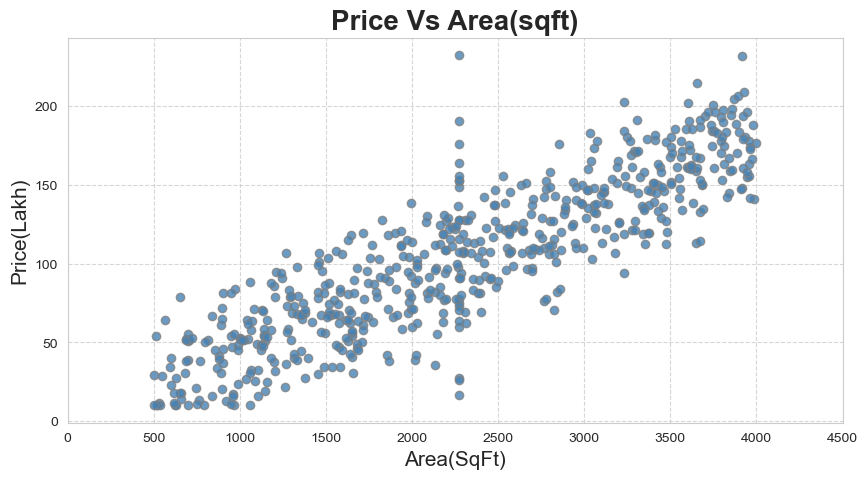

In [37]:
plt.figure(figsize=(10,5))
sns.set_style('whitegrid')

plt.scatter(df_copy['area_sqft'],df_copy['price_lakh'],color='steelblue',alpha=0.8,edgecolors='grey')
plt.title('Price Vs Area(sqft)',weight = 'bold',fontsize=20)
plt.xlabel("Area(SqFt)",fontsize=15)
plt.ylabel("Price(Lakh)",fontsize=15)
plt.grid(True,alpha=0.8,linestyle='--')
plt.xlim(0,4500)


plt.show()

# **Data Preperation**

In [19]:
X = df_copy[['area_sqft','distance_to_metro_km','has_parking','bedrooms']]
Y = df_copy['price_lakh']

print("X shape:", X.shape)
print("y shape:", Y.shape)
print()
print("Features:")
print(X.head())

X shape: (599, 4)
y shape: (599,)

Features:
   area_sqft  distance_to_metro_km  has_parking  bedrooms
0     3674.0                  18.0        False         2
1     1360.0                  18.0         True         3
2     1794.0                  12.7         True         3
3     1630.0                  19.1         True         4
4     1595.0                   5.3         True         3


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,                # features
    Y,                # target
    test_size=0.6,    # 40% goes to test
    random_state=42   # same split every time you run
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (239, 4)
X_test shape:  (360, 4)
y_train shape: (239,)
y_test shape:  (360,)


In [21]:
# Null values check
print("Nulls in X_train:", X_train.isnull().sum().sum())
print("Nulls in y_train:", y_train.isnull().sum())

Nulls in X_train: 0
Nulls in y_train: 0


# **Model**

## *Train*

In [22]:
Model = LinearRegression()

In [23]:
# Train the model 
Model.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [24]:
# See What The Model Learned
print(f"Intercept (β₀): {Model.intercept_:.4f}")
print()
print("Feature Coefficients:")
for feature, coef in zip(X.columns, Model.coef_):
    print(f"  {feature:22} → {coef:.4f}")

Intercept (β₀): 13.7977

Feature Coefficients:
  area_sqft              → 0.0438
  distance_to_metro_km   → -1.8245
  has_parking            → 3.9727
  bedrooms               → 7.2779


## *Test*

In [25]:
# Predict lap times for test set
y_pred = Model.predict(X_test)

# Compare actual vs predicted — first 10 rows
comparison = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred.round(3),
    'Difference': (y_test.values - y_pred).round(3)
})

print(comparison.head(10))

   Actual  Predicted  Difference
0   23.56     24.672      -1.112
1  106.16    112.674      -6.514
2  167.96    168.076      -0.116
3  107.56    116.842      -9.282
4  184.43    190.683      -6.253
5  128.95    122.899       6.051
6   75.42     75.335       0.085
7  137.39    138.510      -1.120
8  130.45    102.224      28.226
9  180.33    181.092      -0.762


## *Evaluation*

In [26]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE:       {mae:.4f}")
print(f"RMSE:      {rmse:.4f}")
print(f"R² Score:  {r2:.4f}")

MAE:       9.6351
RMSE:      14.2134
R² Score:  0.9202


# **Visualisation**

## *Actual Vs Pridicted*

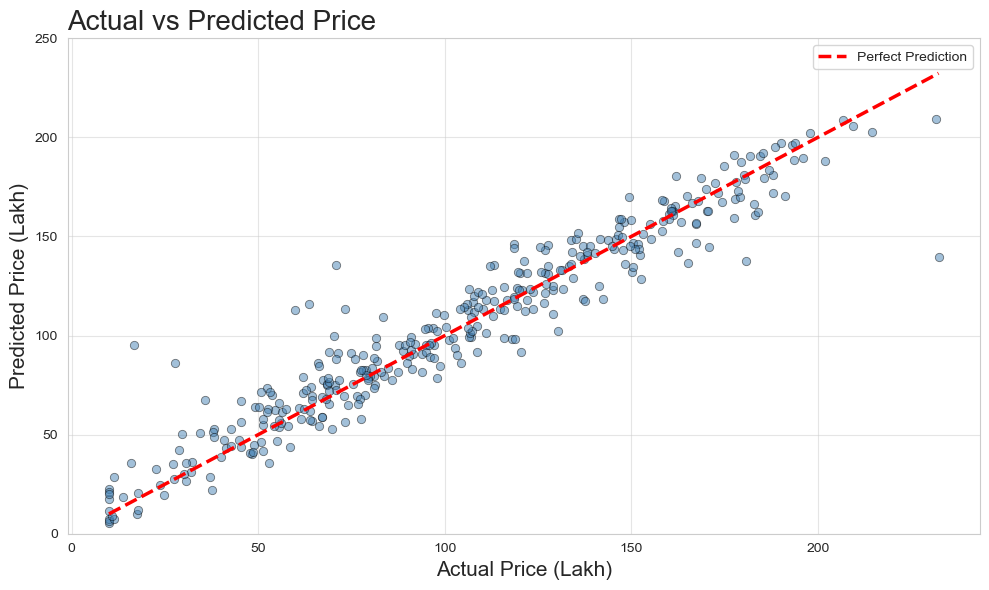

In [34]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, color='steelblue', alpha=0.5, edgecolors='black', linewidth=0.6)

# Perfect prediction line — if every prediction was exact
# all dots would sit on this line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2.5, linestyle='--', label='Perfect Prediction')

plt.legend()
plt.xlabel('Actual Price (Lakh)',fontsize=15)
plt.ylabel('Predicted Price (Lakh)',fontsize=15)
plt.title('Actual vs Predicted Price',fontsize=20,loc='left')
plt.grid(True,alpha=0.5)
plt.ylim(0,250)
plt.tight_layout()
plt.show()